In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [59]:
 df = pd.read_csv("HR-Employee-Attrition.csv")

In [60]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [61]:
df.describe().all

<bound method DataFrame.all of                Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
st

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [63]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [64]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [65]:
# Missing Values
#No missing values were identified in the dataset, so no missing-value
#imputation or row removal was required.

In [66]:
df.value_counts().sum()

np.int64(1470)

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
### Duplicate Records

No completely duplicated employee records were found.
Therefore, no duplicate rows needed to be removed.

SyntaxError: invalid syntax (893845161.py, line 3)

In [69]:
df = df.drop(columns = ["EmployeeNumber", "Over18", "StandardHours"])

In [70]:
df.head().all

<bound method DataFrame.all of    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  \
0                 1          2  Life Sciences              1   
1                 8          1  Life Sciences              1   
2                 2          2          Other              1   
3                 3          4  Life Sciences              1   
4                 2          1        Medical              1   

   EnvironmentSatisfaction  ... PerformanceRating  RelationshipSatisfaction  \
0                        2  ...                 3           

In [71]:
df.describe().all

<bound method DataFrame.all of                Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EnvironmentSatisfaction   HourlyRate  JobInvolvement     JobLevel  \
count              1470.000000  1470.000000     1470.000000  1470.000000   
mean                  2.721769    65.891156        2.729932     2.063946   
std        

In [72]:
### Irrelevant Features Removed

`EmployeeCount`, `Over18`, and `StandardHours` were removed because those are not releveant to the solution and contain only one value therefore provide no useful variation.

SyntaxError: invalid syntax (3588030503.py, line 3)

AttributeError: 'DataFrame' object has no attribute 'show'

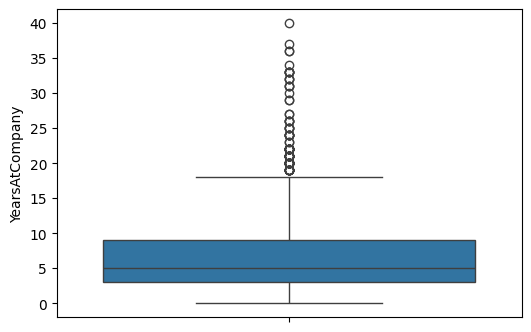

In [73]:
plt.figure(figsize = (6,4))
sns.boxplot(df['YearsAtCompany'])
df.show()

AttributeError: 'DataFrame' object has no attribute 'show'

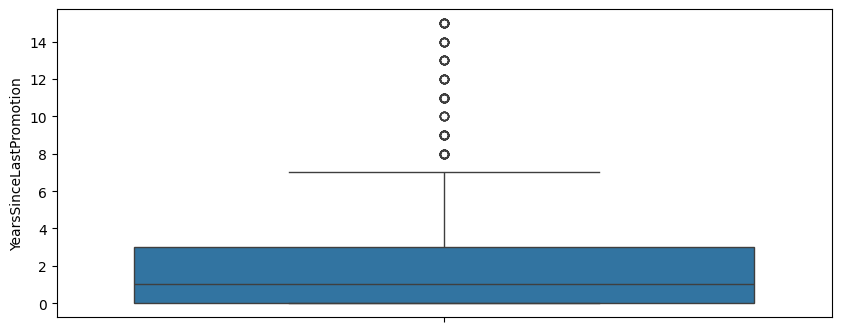

In [74]:
plt.figure(figsize = (10,4))
sns.boxplot(df["YearsSinceLastPromotion"])
df.show

AttributeError: 'DataFrame' object has no attribute 'show'

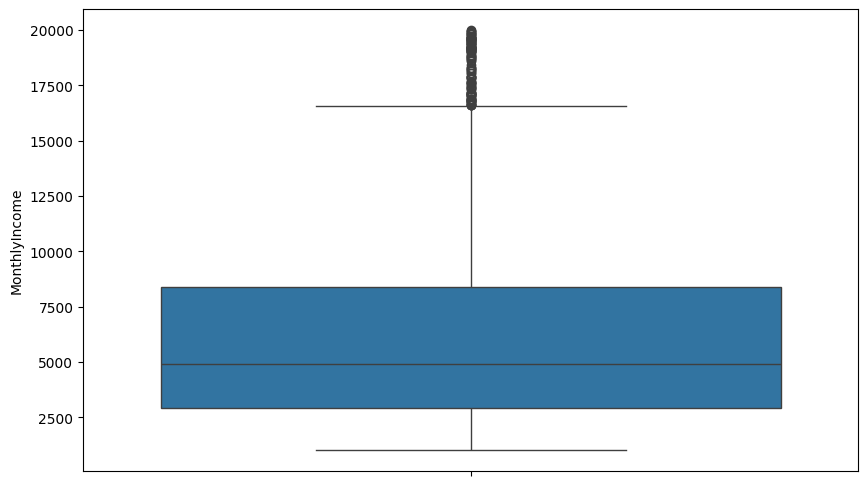

In [75]:
plt.figure(figsize = (10,6))
sns.boxplot(df['MonthlyIncome'])
df.show()

In [ ]:
###Outliers

All of the above contains outliers but we shouldnt remove now because they provide value to dataset rather than errors,so i not performing any action for now

In [ ]:
# Visualizations

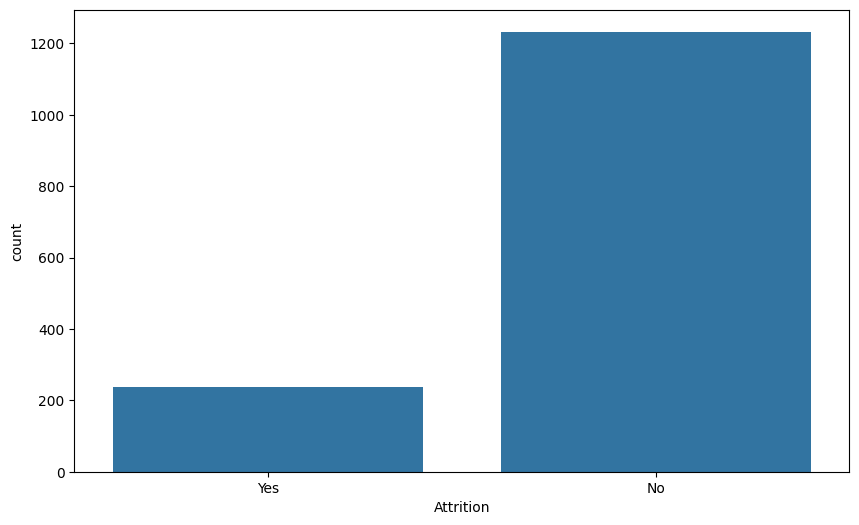

In [76]:
plt.figure(figsize= (10,6))
sns.countplot(data = df, x="Attrition")
plt.show()

In [ ]:
# This indicates the target variable is imbalanced.We could less number of people are levaing the company and this should be handled at next steps.

AttributeError: 'DataFrame' object has no attribute 'show'

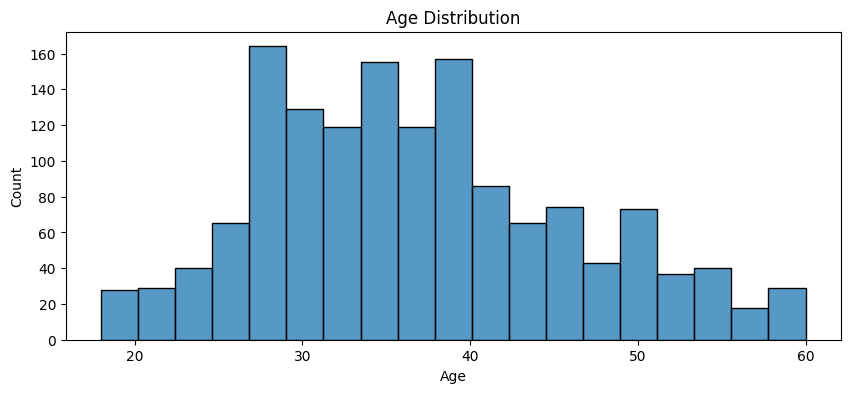

In [77]:
plt.figure(figsize = (10, 4))
sns.histplot(data = df, x = 'Age')
plt.title('Age Distribution')
df.show()


AttributeError: 'DataFrame' object has no attribute 'show'

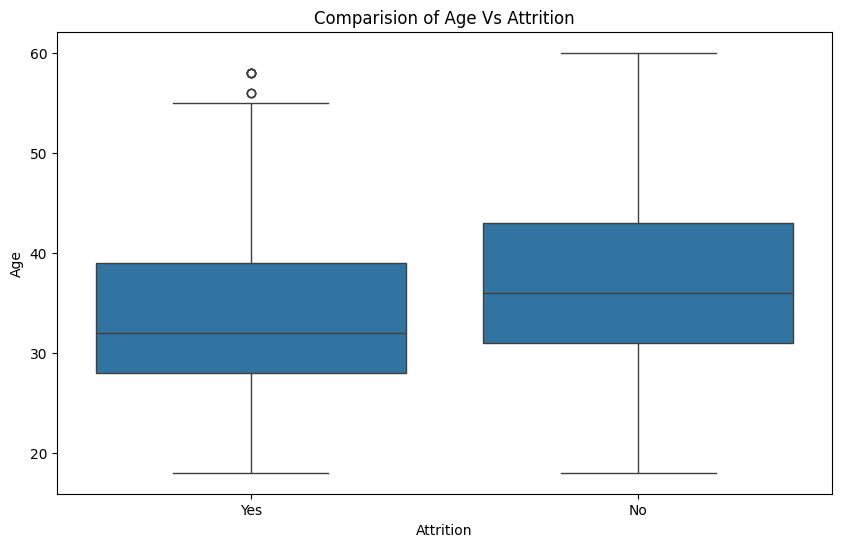

In [78]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x="Attrition", y= "Age")
plt.title("Comparision of Age Vs Attrition")
df.show()

AttributeError: 'DataFrame' object has no attribute 'show'

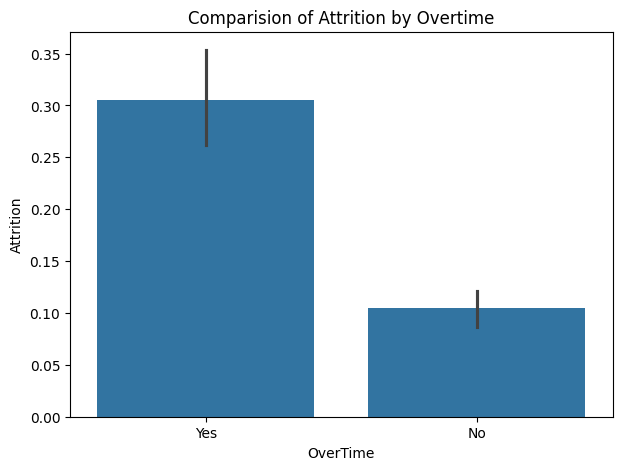

In [88]:
plt.figure(figsize=(7, 5))
sns.barplot(data = df, x = "OverTime", y = "Attrition")
plt.title('Comparision of Attrition by Overtime')
df.show()

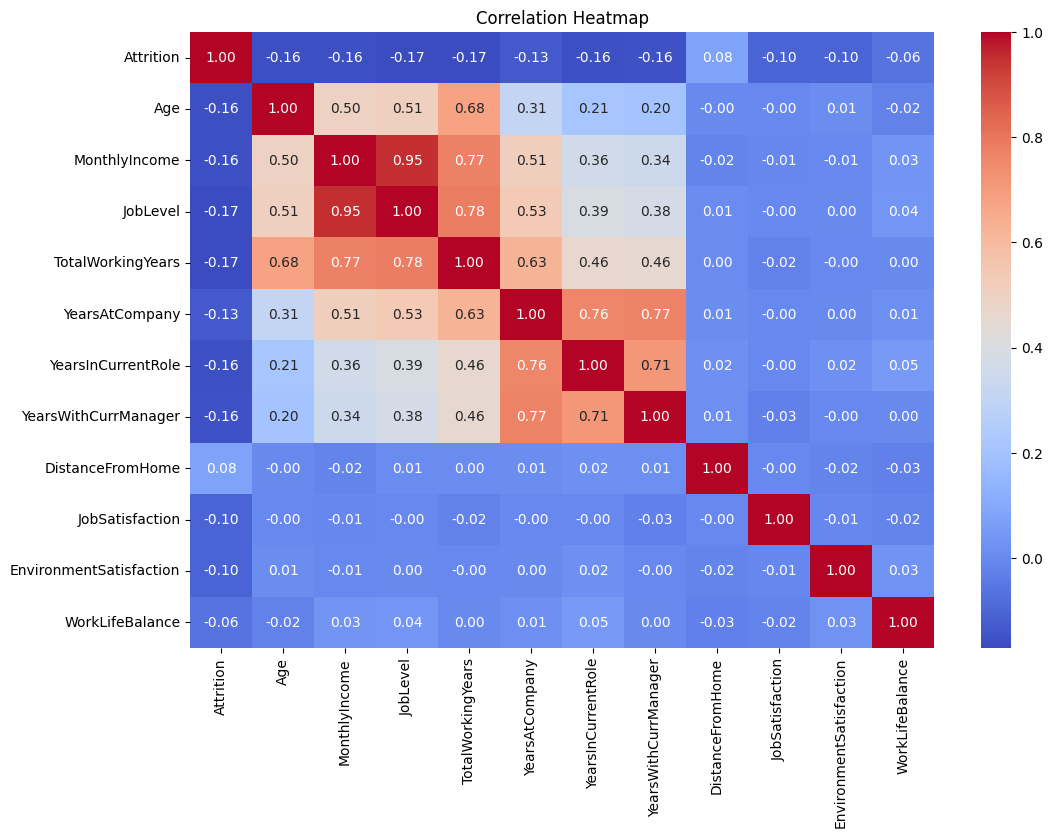

In [93]:

correlation_columns = [
    "Attrition",
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "DistanceFromHome",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance"]
corr = df[correlation_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [100]:
job_role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values() * 100
)

job_role_attrition

JobRole
Research Director             2.500000
Manager                       4.901961
Healthcare Representative     6.870229
Manufacturing Director        6.896552
Research Scientist           16.095890
Sales Executive              17.484663
Human Resources              23.076923
Laboratory Technician        23.938224
Sales Representative         39.759036
Name: Attrition, dtype: float64

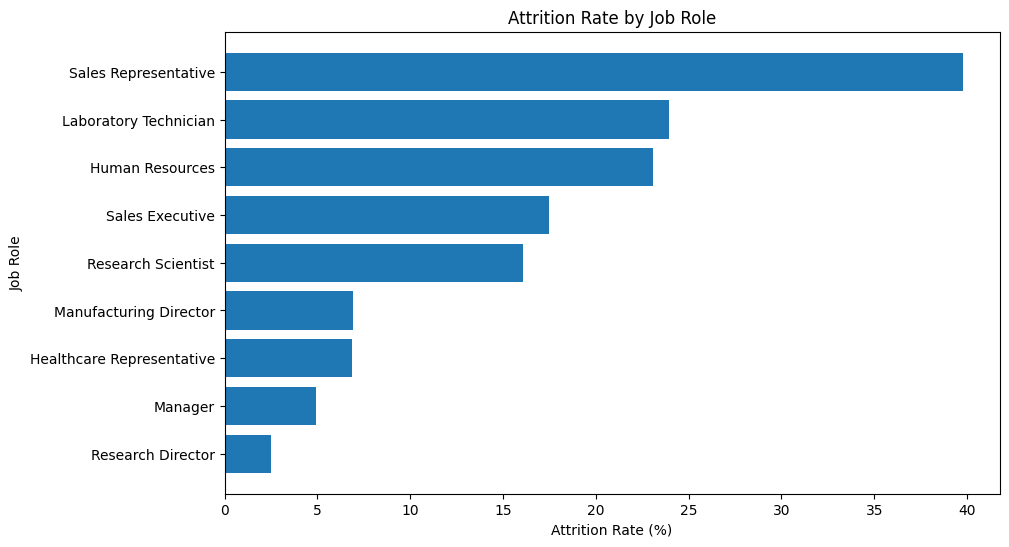

In [101]:
plt.figure(figsize=(10, 6))

plt.barh(
    job_role_attrition.index,
    job_role_attrition.values
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

In [ ]:
#Feature Engineering

In [102]:
# Income Per Experience Year
df["IncomePerYearExperience"] = (df["MonthlyIncome"] /(df["TotalWorkingYears"] + 1))

In [103]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerYearExperience
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,665.888889
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,...,4,1,10,3,3,10,7,1,7,466.363636
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,0,7,3,3,0,0,0,0,261.250000
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,...,3,0,8,3,3,8,7,3,0,323.222222
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,4,1,6,3,3,2,2,2,2,495.428571


In [ ]:
#IncomePerYearExperience was created to capture compensation relative to an employee's total professional experience. Employees with similar experience but different compensation may exhibit different attritionpatterns.

In [104]:
#Overall Satisfaction
df["OverallSatisfaction"] = (df[["EnvironmentSatisfaction","JobSatisfaction","RelationshipSatisfaction","WorkLifeBalance"]].mean(axis=1))

In [105]:
df[["EnvironmentSatisfaction","JobSatisfaction","RelationshipSatisfaction","WorkLifeBalance","OverallSatisfaction"]].head()

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,OverallSatisfaction
0,2,4,1,1,2.00
1,3,2,4,3,3.00
2,4,3,2,3,3.00
3,4,3,3,3,3.25
4,1,2,4,3,2.50


In [106]:
#Company Tenure Ratio
df["CompanyTenureRatio"] = (df["YearsAtCompany"] /(df["TotalWorkingYears"] + 1))

In [107]:
df[["YearsAtCompany","TotalWorkingYears","CompanyTenureRatio"]].head()

,YearsAtCompany,TotalWorkingYears,CompanyTenureRatio
0,6,8,0.666667
1,10,10,0.909091
2,0,7,0.000000
3,8,8,0.888889
4,2,6,0.285714


In [ ]:
#`CompanyTenureRatio` measures how much of an employee's total career has been spent at the current company. It may help distinguish long-term committed employees from employees who frequently change employers.

In [108]:
df["EarlyCareerEmployee"] = (df["TotalWorkingYears"] <= 5).astype(int)

In [110]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

In [112]:
df.groupby("OverTime")["Attrition"].mean() * 100

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

In [113]:
df.groupby("Attrition")["Age"].mean()

Attrition
0    37.561233
1    33.607595
Name: Age, dtype: float64

In [114]:
df.groupby("Attrition")["MonthlyIncome"].median()

Attrition
0    5204.0
1    3202.0
Name: MonthlyIncome, dtype: float64

In [115]:
df.groupby("Attrition")["YearsAtCompany"].median()

Attrition
0    6.0
1    3.0
Name: YearsAtCompany, dtype: float64

In [ ]:
'''Key Findings

1. Employee attrition is relatively imbalanced.Around 16% of employees in the dataset left the company, while approximately 84% remained.

2. Overtime appears to be an important attrition factor.Employees who work overtime show a noticeably higher attrition rate compared with employees who do not work overtime.

3. Younger employees are more likely to leave.** Employees who experienced attrition have a lower average age compared with employees who stayed.

4.Income appears to be associated with attrition.Employees who left generally have a lower median monthly income than employees who remained with the company.

5. Employee tenure is associated with attrition.Employees who leave generally have fewer years at the company, suggesting that attrition risk may be higher during the earlier stages of employment.'''

In [116]:
df.to_csv(
    "IBM_HR_Attrition_Cleaned.csv",
    index=False
)